# DAG Learning

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re  # For extracting numbers from filenames
import os 
# Define parameters
#root_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs_mtx/logs_adni_all/2025-06-23T12-49-18-textcond_six_10slice_reg5e8_epoch5_reg"
#celeba
#root_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs_mtx/logs_celeA_complex_all/2025-06-24T09-31-38-textcond_noreg_epoch5_balancer_reg_nomask_accum2"
#pendulum
root_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs_mtx/logs_pendulum_all/2025-02-25T13-44-53-accu100_DAG3_warmup_lr5e04_cosineschedule_reg1"
# Load all CM files dynamically
cm_files = glob.glob(os.path.join(root_path ,"CM-*.csv"))

# Extract numerical part of filenames for proper sorting
def extract_number(filename):
    match = re.search(r'CM-(\d+)\.csv', filename)
    return int(match.group(1)) if match else float('inf')

# Sort files numerically based on extracted numbers

cm_files = sorted(cm_files, key=extract_number)

# Check if any files were found
if not cm_files:
    print("No causal matrix files found!")

# Load all matrices
cm_matrices = [np.loadtxt(file, delimiter=",") for file in cm_files]
num_matrices = len(cm_matrices)

# Compute global min/max across all matrices for consistent color scaling
cm_min = min(matrix.min() for matrix in cm_matrices)
cm_max = max(matrix.max() for matrix in cm_matrices)
print('Dataset is',root_path.split('/')[-2])
print('total_matrix',num_matrices)

Dataset is logs_pendulum_all
total_matrix 150


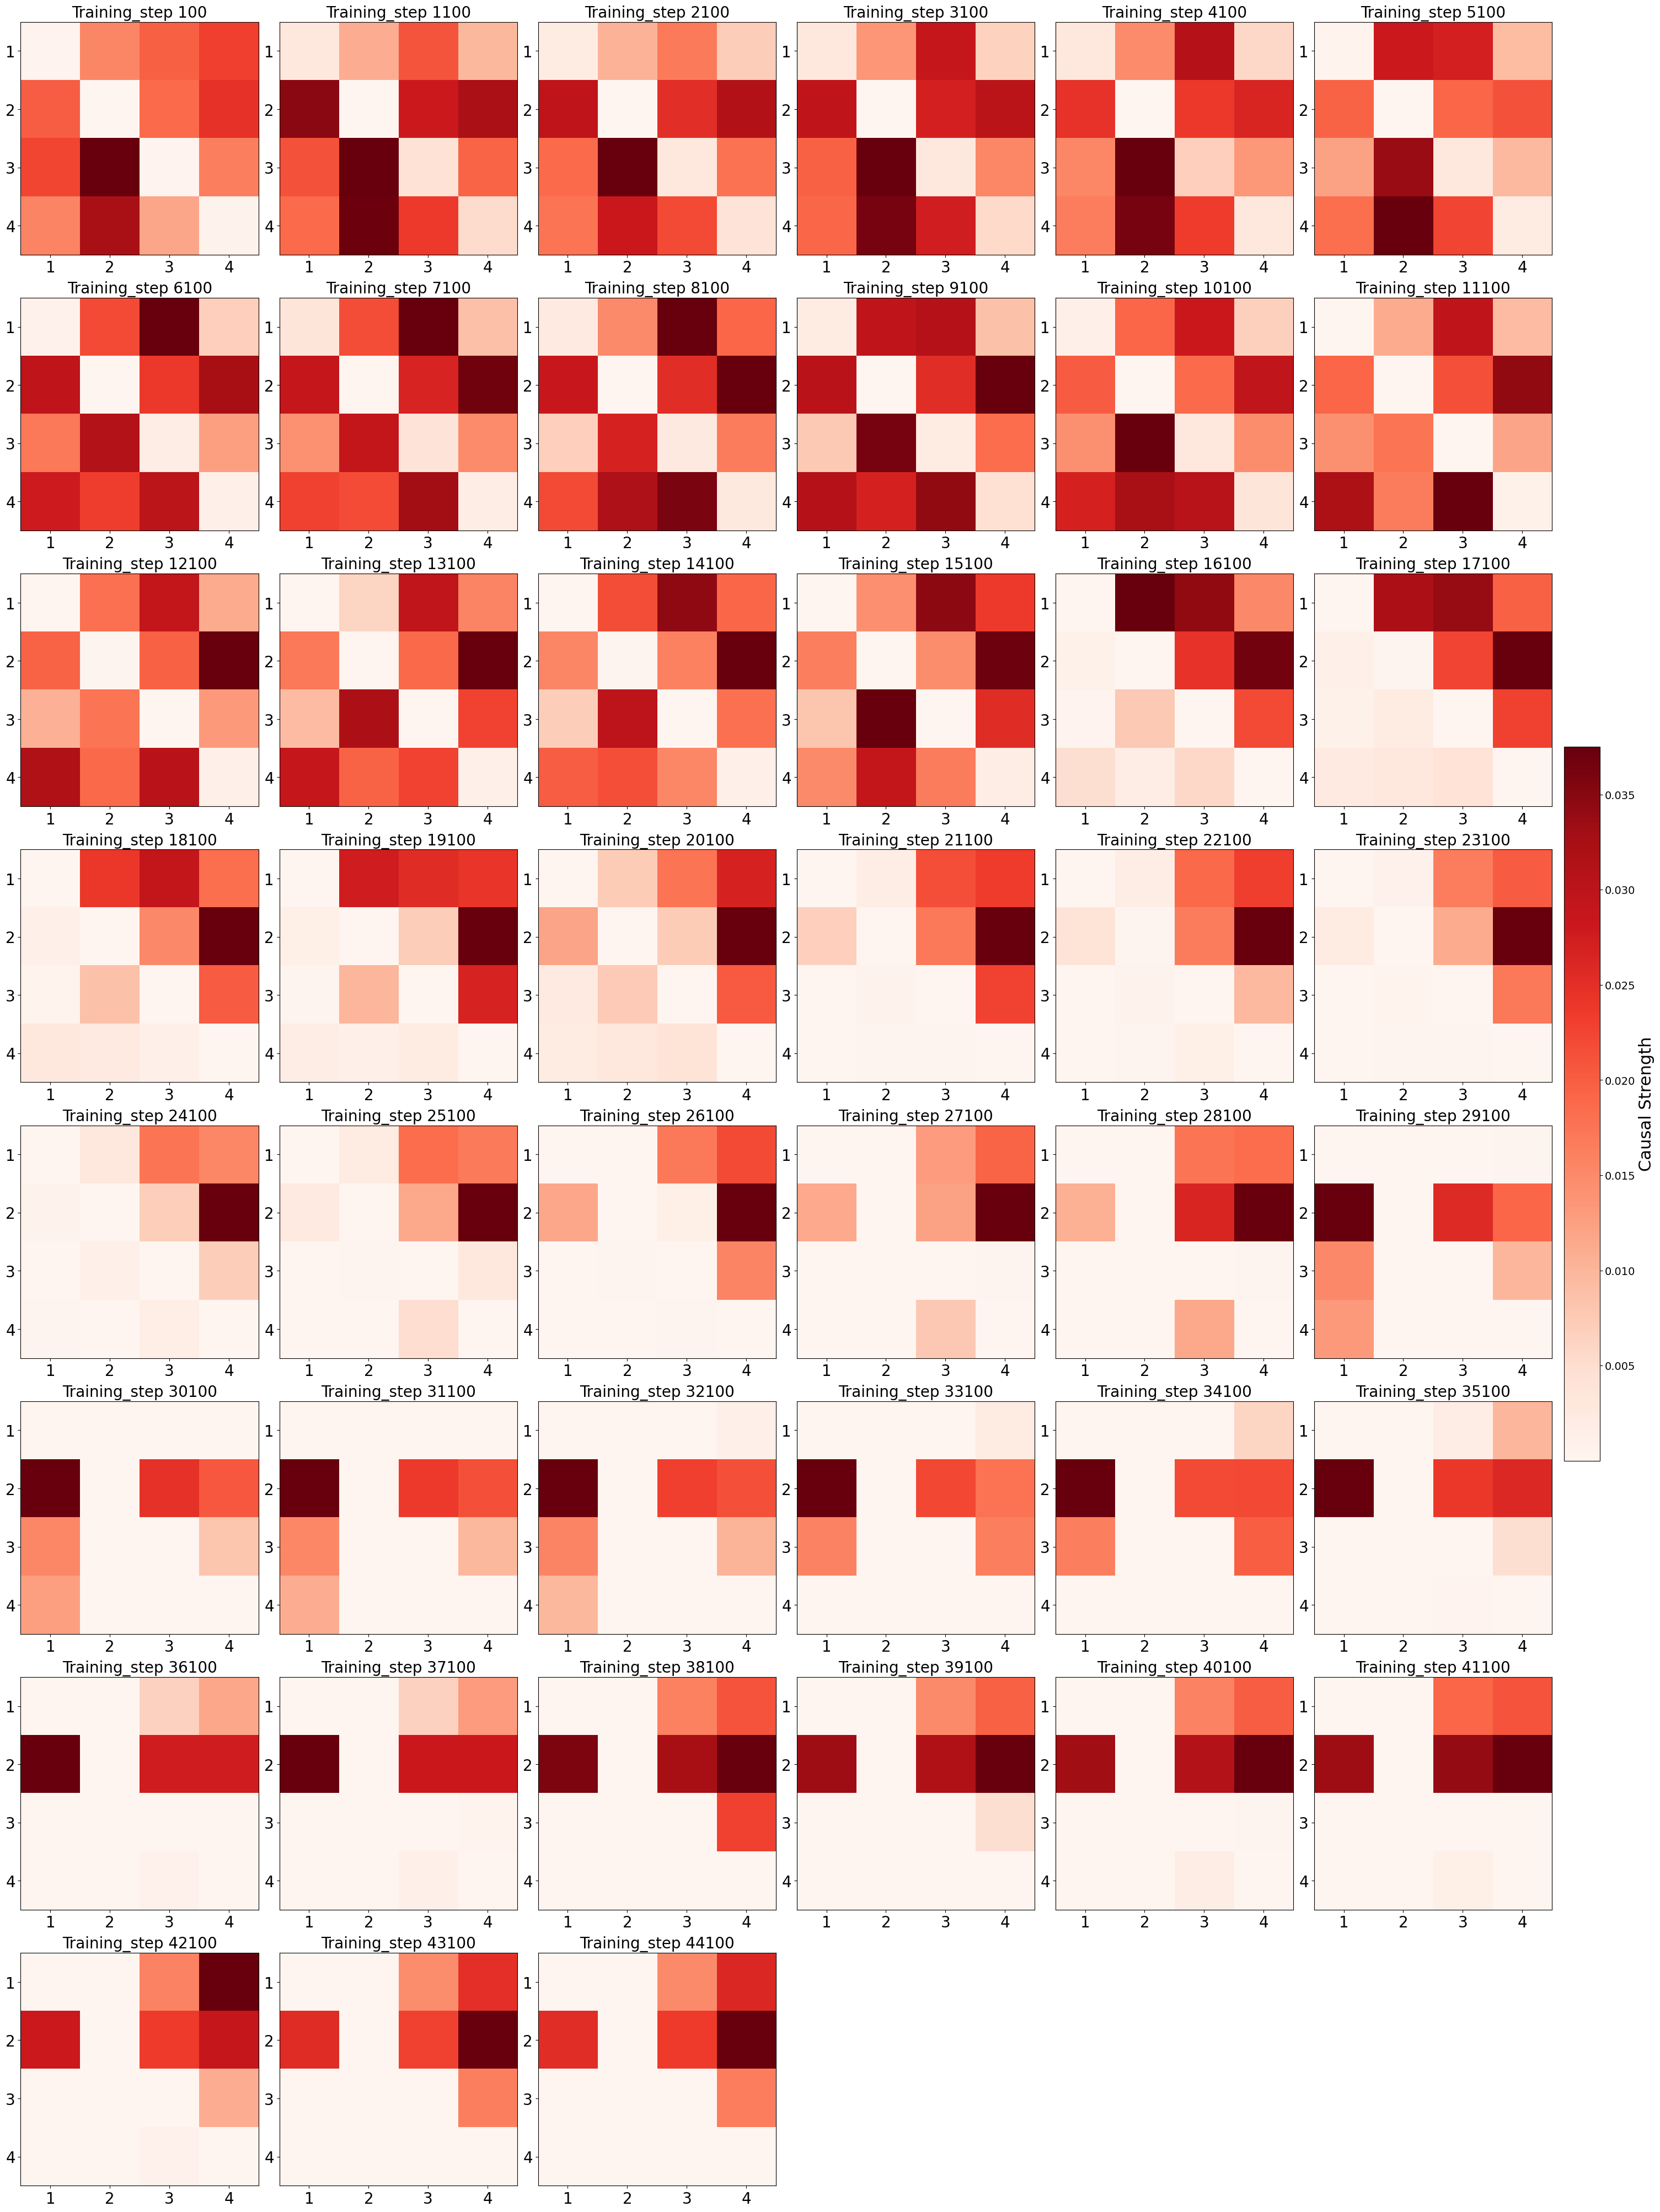

In [6]:
# Set up plot grid (auto-adjusting)
# step_gap 1 for normal 100 training steps
step_gap = 10
cm_threshold = 0.0
gapped_cm_matrices = cm_matrices[:][::step_gap][:]
gapped_cm_files = cm_files[:][::step_gap][:]
num_gapped_matrices = len(gapped_cm_matrices)

matrix_h, matrix_w = gapped_cm_matrices[0].shape

cm_min = min(matrix.min() for matrix in gapped_cm_matrices)
cm_max = max(matrix.max() for matrix in gapped_cm_matrices)

cols = 6  # Number of columns
rows = (num_gapped_matrices + cols - 1) // cols  # Compute required rows

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=True)

# Ensure `axes` remains a 2D array (no flattening)
if rows == 1:
    axes = np.expand_dims(axes, axis=0)  # Convert to 2D if there's only one row
if cols == 1:
    axes = np.expand_dims(axes, axis=1)  # Convert to 2D if there's only one column

# Plot each matrix
for idx, (cm, file_name) in enumerate(zip(gapped_cm_matrices, gapped_cm_files)):
    th_cm = cm.copy()
    th_cm[np.abs(th_cm)<cm_threshold]=0
    row, col = divmod(idx, cols)  # Compute row and column index
    ax = axes[row, col]
    im = ax.imshow(th_cm, cmap="Reds", aspect="auto")
    #im = ax.imshow(cm, cmap="Reds", aspect="auto", vmin=cm_min, vmax=cm_max)
    ax.set_title('Training_step '+file_name.split("/")[-1].split('.')[0].split('-')[-1],fontsize=20)  # Extract filename
     # Set custom x-ticks and y-ticks based on the matrix size
    ax.set_xticks(np.arange(matrix_w))  # 0, 1, 2, ..., W-1
    ax.set_yticks(np.arange(matrix_h))  # 0, 1, 2, ..., H-1

    # Label x-ticks and y-ticks from 1 to W and 1 to H
    ax.set_xticklabels(np.arange(1, matrix_w + 1),fontsize=20)
    ax.set_yticklabels(np.arange(1, matrix_h + 1),fontsize=20)

    # Rotate x-tick labels for better readability if needed
    #ax.tick_params(axis="x", rotation=45) 

# Remove extra subplots (if any)
for idx in range(num_gapped_matrices, rows * cols):
    row, col = divmod(idx, cols)
    fig.delaxes(axes[row, col])

# Add a single global colorbar outside the grid
cbar = fig.colorbar(im,ax=axes[:,cols-1], label="Causal Strength")
cbar.ax.tick_params(labelsize=14)  # Increase colorbar tick label size
cbar.set_label("Causal Strength", fontsize=22)

plt.show()

## Metrics

In [4]:
import numpy as np
from scipy.special import expit as sigmoid
import igraph as ig
import random


def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)


def is_dag(W):
    G = ig.Graph.Weighted_Adjacency(W.tolist())
    return G.is_dag()
def count_accuracy(B_true: np.ndarray, B_est: np.ndarray) -> dict:
    r"""
    Compute various accuracy metrics for B_est.

    | true positive = predicted association exists in condition in correct direction
    | reverse = predicted association exists in condition in opposite direction
    | false positive = predicted association does not exist in condition
    
    Parameters
    ----------
    B_true : np.ndarray
        :math:`[d, d]` ground truth graph, :math:`\{0, 1\}`.
    B_est : np.ndarray
        :math:`[d, d]` estimate, :math:`\{0, 1, -1\}`, -1 is undirected edge in CPDAG.

    Returns
    -------
    dict
        | fdr: (reverse + false positive) / prediction positive
        | tpr: (true positive) / condition positive
        | fpr: (reverse + false positive) / condition negative
        | shd: undirected extra + undirected missing + reverse
        | nnz: prediction positive
    """
    if (B_est == -1).any():  # cpdag
        if not ((B_est == 0) | (B_est == 1) | (B_est == -1)).all():
            raise ValueError('B_est should take value in {0,1,-1}')
        if ((B_est == -1) & (B_est.T == -1)).any():
            raise ValueError('undirected edge should only appear once')
    else:  # dag
        if not ((B_est == 0) | (B_est == 1)).all():
            raise ValueError('B_est should take value in {0,1}')
        if not is_dag(B_est):
            raise ValueError('B_est should be a DAG')
    d = B_true.shape[0]
    # linear index of nonzeros
    pred_und = np.flatnonzero(B_est == -1)
    pred = np.flatnonzero(B_est == 1)
    cond = np.flatnonzero(B_true)
    cond_reversed = np.flatnonzero(B_true.T)
    cond_skeleton = np.concatenate([cond, cond_reversed])
    # true pos
    true_pos = np.intersect1d(pred, cond, assume_unique=True)
    # treat undirected edge favorably
    true_pos_und = np.intersect1d(pred_und, cond_skeleton, assume_unique=True)
    true_pos = np.concatenate([true_pos, true_pos_und])
    # false pos
    false_pos = np.setdiff1d(pred, cond_skeleton, assume_unique=True)
    false_pos_und = np.setdiff1d(pred_und, cond_skeleton, assume_unique=True)
    false_pos = np.concatenate([false_pos, false_pos_und])
    # reverse
    extra = np.setdiff1d(pred, cond, assume_unique=True)
    reverse = np.intersect1d(extra, cond_reversed, assume_unique=True)
    # compute ratio
    pred_size = len(pred) + len(pred_und)
    cond_neg_size = 0.5 * d * (d - 1) - len(cond)
    fdr = float(len(reverse) + len(false_pos)) / max(pred_size, 1)
    tpr = float(len(true_pos)) / max(len(cond), 1)
    fpr = float(len(reverse) + len(false_pos)) / max(cond_neg_size, 1)
    # structural hamming distance
    pred_lower = np.flatnonzero(np.tril(B_est + B_est.T))
    cond_lower = np.flatnonzero(np.tril(B_true + B_true.T))
    extra_lower = np.setdiff1d(pred_lower, cond_lower, assume_unique=True)
    missing_lower = np.setdiff1d(cond_lower, pred_lower, assume_unique=True)
    shd = len(extra_lower) + len(missing_lower) + len(reverse)
    return {'fdr': fdr, 'tpr': tpr, 'fpr': fpr, 'shd': shd, 'nnz': pred_size}

In [5]:
B_true =np.array([[0,0,1.0,1.0],
                   [0,0,1.0,1.0],
                   [0,0,0,0],
                   [0,0,0,0],
                   ])
pred = np.array([[0,1.0,1.0,1.0],
                   [0,0,0.0,0.0],
                   [0,0,0,0],
                   [0,1.0,0,0],
                   ])
acc = count_accuracy(B_true,th_cm!=0 )
print(acc)

ValueError: B_est should be a DAG

In [5]:
cm_threshold = 0.0
th_cm = gapped_cm_matrices[-1].copy()
# th_cm = cm_matrices[-1].copy()
th_cm[np.abs(th_cm)<cm_threshold]=0
th_cm

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.94672719e-02, 0.00000000e+00,
        1.65134910e-02, 0.00000000e+00],
       [0.00000000e+00, 9.05129764e-06, 0.00000000e+00, 3.18754724e-06,
        5.21762704e-04, 9.14168959e-06],
       [0.00000000e+00, 0.00000000e+00, 2.82969922e-02, 0.00000000e+00,
        1.73697118e-02, 7.84991076e-04],
       [0.00000000e+00, 3.15878169e-05, 1.31335882e-02, 4.91725841e-05,
        0.00000000e+00, 4.45417063e-05],
       [0.00000000e+00, 0.00000000e+00, 1.83328968e-02, 4.40934999e-03,
        1.24754561e-02, 0.00000000e+00]])

# Check one cell value change curve

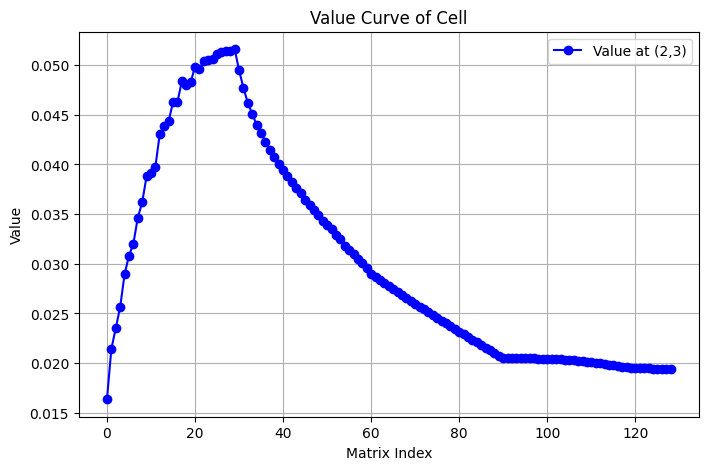

In [7]:
import numpy as np
import matplotlib.pyplot as plt


matrices = cm_matrices

# Choose a specific cell (row, col) to track
row, col = 2,3  # Example: Track the value of the cell at (2,3)

# Extract values from the matrices
cell_values = [mat[row-1, col-1] for mat in matrices]
cell_values_transpose = [mat[col-1, row-1] for mat in matrices]

# Plot the value curve
plt.figure(figsize=(8, 5))
plt.plot(cell_values, marker='o', linestyle='-', color='b', label=f'Value at ({row},{col})')
#plt.plot(cell_values_transpose, marker='o', linestyle='-', color='r', label=f'Value at ({col},{row})')
plt.xlabel('Matrix Index')
plt.ylabel('Value')
plt.title(f'Value Curve of Cell')
plt.legend()
plt.grid(True)
plt.show()


# Test code

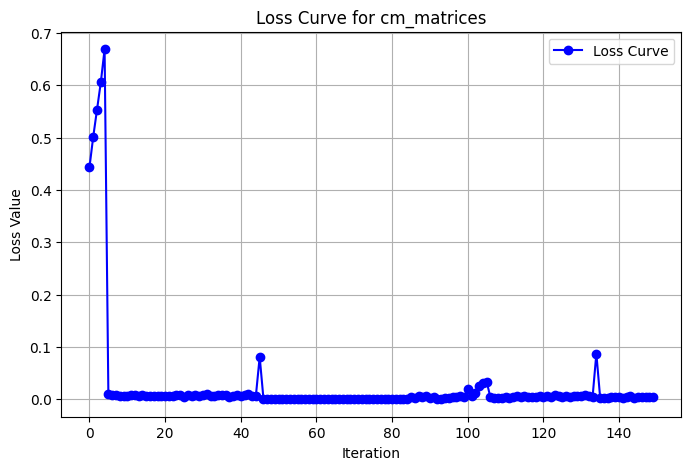

In [49]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Example input: List of cm_matrices
d = cm_matrices[0].shape[0]  # Matrix dimension
s = 1.0  # Scaling factor (adjust based on context)
I = torch.eye(d)  # Identity matrix

# Store loss values
loss_values = []
sum_weights = []
# Compute loss for each matrix in cm_matrices
for A in cm_matrices:
    A_torch = torch.from_numpy(A)

    #A_torch = torch.pow(torch.from_numpy(A),2)

    h = -torch.slogdet(s * I.to(A_torch.device) - A_torch)[1] + d * np.log(s)
    loss_values.append(h.mean().item())  # Store mean loss
    sum_weights.append(torch.sum(A_torch).item())
# Plot the loss curve
plt.figure(figsize=(8, 5))
plt.plot(loss_values, marker='o', linestyle='-', color='b', label="Loss Curve")
#plt.plot(sum_weights, marker='o', linestyle='-', color='r', label="sum weights")
plt.xlabel("Iteration")
plt.ylabel("Loss Value")
plt.title("Loss Curve for cm_matrices")
plt.legend()
plt.grid(True)
plt.show()


In [48]:
A_torch = torch.from_numpy(cm_matrices[0])
print(A_torch)

print(-torch.slogdet(s * I.to(A_torch.device) - A_torch*A_torch)[1] + d * np.log(s))

tensor([[0.0017, 0.0432, 0.0760, 0.0480],
        [0.0500, 0.0027, 0.0588, 0.0520],
        [0.0461, 0.0512, 0.0039, 0.0518],
        [0.0423, 0.0410, 0.0408, 0.0011]], dtype=torch.float64)
tensor(6.5494e-05, dtype=torch.float64)


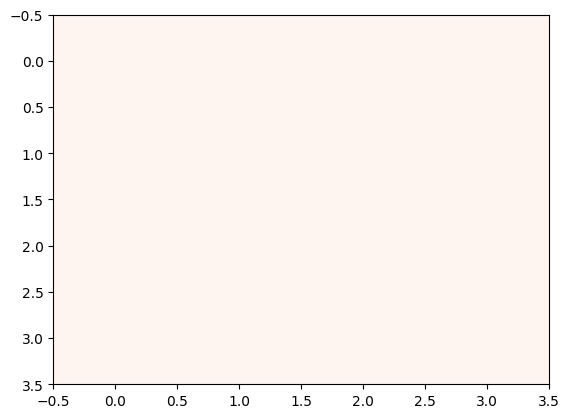

In [4]:
import numpy as np
import matplotlib.pyplot as plt
file = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs_mtx/logs_pendulum_all/2025-02-17T23-57-22-cd_only_attr_only_DAG_loss/CM-200.csv'
cm_matx = np.loadtxt(file, delimiter=",")
plt.imshow(cm_matx,cmap="Reds", aspect="auto")

In [14]:
import torch
s = 1.0
d = 4
mtx = np.loadtxt('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs_mtx/logs_pendulum_all/2025-02-18T22-48-56-cd_only_attr_accu100_BN/CM-5000.csv',delimiter=',') 
A = torch.from_numpy(mtx)
I = torch.eye(d)
A = torch.tensor([[0.0035, 0.0035, 0.0035, 0.0035],
        [0.0035, 0.0035, 0.0035, 0.0035],
        [0.0035, 0.0035, 0.0035, 0.0035],
        [0.0035, 0.0035, 0.0035, 0.0035]])
A = torch.sqrt(A)
h = -torch.slogdet(s * I.to(A.device) - A)[1] + d * np.log(s)
print(A)
print('loss',h.mean())

tensor([[0.0592, 0.0592, 0.0592, 0.0592],
        [0.0592, 0.0592, 0.0592, 0.0592],
        [0.0592, 0.0592, 0.0592, 0.0592],
        [0.0592, 0.0592, 0.0592, 0.0592]])
loss tensor(0.2700)


In [53]:
import torch
a= torch.randn((4,4,2))
fc1_weight = a.view(4, -1, 4)  
A = torch.sum(fc1_weight ** 2, dim=1).t() 
W = torch.sqrt(A)
W = W.cpu().detach().numpy()  # [i, j]
W

array([[1.4043933 , 0.89136976, 0.5264148 , 1.3701694 ],
       [0.29134524, 0.7018763 , 0.64250976, 1.1750436 ],
       [2.0987556 , 0.6113259 , 2.110721  , 0.64590544],
       [1.5793283 , 1.0106145 , 0.7457823 , 0.988698  ]], dtype=float32)

In [54]:
torch.linalg.vector_norm(a, dim=2, ord=2)

tensor([[0.4532, 1.7567, 1.3608, 1.9527],
        [0.4061, 0.9825, 1.0594, 0.6556],
        [0.7773, 0.2463, 0.2928, 2.2250],
        [1.3611, 0.4756, 1.1856, 1.0810]])

In [13]:
import torch

def get_attribute_ids(attribute_size):
    attribute_indices = {}
    idx = 0
    for attr, size in attribute_size.items():
        attribute_indices[attr] = list(range(idx, idx + size))
        idx += size
    return attribute_indices

class SelectParentAttributesTransform:
    def __init__(self, name, attribute_size, graph_structure):
        self.name = name
        attribute_indices = get_attribute_ids(attribute_size)

        self.attr_ids = attribute_indices[name] if self.name != 'image' else None
        self.pa_ids = sum([attribute_indices[attr] for attr in graph_structure[name]], [])

    def __call__(self, img, attrs):
        if self.name == 'image':
            return img, torch.Tensor([attrs[idx] for idx in self.pa_ids])
        else:
            return torch.Tensor([attrs[idx] for idx in self.attr_ids]), torch.Tensor([attrs[idx] for idx in self.pa_ids])

class ReturnDictTransform:
    def __init__(self, attribute_size):
        self.attribute_ids = get_attribute_ids(attribute_size)

    def __call__(self, img, attrs):
        return {**{"image": img}, **{attr: attrs[ids] for attr, ids in self.attribute_ids.items()}}


a = dict({
    "causal_graph": {
        "thickness": [],
        "intensity": ["thickness"],
        "digit": [],
        "image": ["thickness", "intensity", "digit"]
    },
    "attribute_size": {
        "thickness": 1,
        "intensity": 1,
        "digit": 10
    },}
    )

transform = SelectParentAttributesTransform("image", a['attribute_size'], a['causal_graph'])


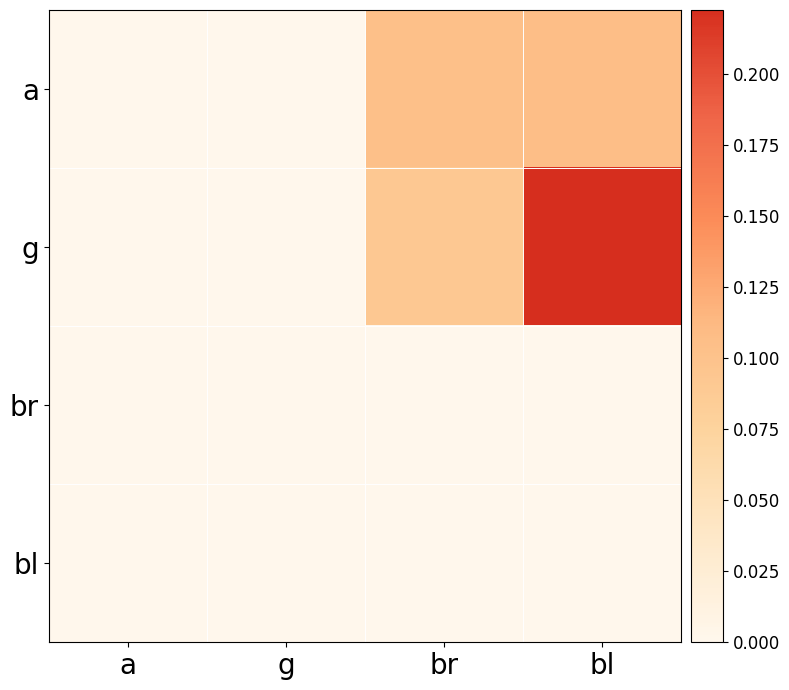

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    new_colors = cmap(np.linspace(minval, maxval, n))
    return LinearSegmentedColormap.from_list("trunc_cmap", new_colors)

def visualize_adjacency_matrix(adj_matrix, x_labels=None, y_labels=None):
    fig, ax = plt.subplots(figsize=(8, 8))

    # vmin/vmax
    vmin = np.min(adj_matrix)
    vmax = np.max(adj_matrix)
    if vmin == vmax:
        vmax = vmin + 1.0

    # colormap
    orig_cmap = plt.get_cmap("OrRd")
    trunc_cmap = truncate_colormap(orig_cmap, 0.0, 0.75)

    # heatmap
    im = ax.imshow(adj_matrix, cmap=trunc_cmap, vmin=vmin, vmax=vmax, aspect='equal')

    # grid lines
    ax.set_xticks(np.arange(-0.5, adj_matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, adj_matrix.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    # axis labels
    if x_labels is None:
        x_labels = [f"A{i}" for i in range(adj_matrix.shape[1])]
    if y_labels is None:
        y_labels = [f"A{i}" for i in range(adj_matrix.shape[0])]

    ax.set_xticks(range(adj_matrix.shape[1]))
    ax.set_yticks(range(adj_matrix.shape[0]))
    ax.set_xticklabels(x_labels, fontsize=20)
    ax.set_yticklabels(y_labels, fontsize=20)

    # ---------------------------------------------------
    # COLORBAR THAT MATCHES MATRIX HEIGHT
    # ---------------------------------------------------
    # Create separate axes for colorbar with matched height
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)

    # create colorbar in the new axis; it will match the height automatically
    cb = plt.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=12)

    # title
    #plt.title("Adjacency Matrix Visualization", fontsize=14)
    plt.tight_layout()
    plt.show()


file_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs_mtx/logs_celeA_complex_all/2025-06-24T09-31-38-textcond_noreg_epoch5_balancer_reg_nomask_accum2/CM-22000.csv"
adj = np.loadtxt(file_path, delimiter=",")
th_cm = adj.copy()
th_cm[np.abs(th_cm)<0.009]=0
adj = th_cm*10

#SDCD
# file_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/causal_discovery/saved_mtx/celeA_complex/SDCD.csv"
# adj = np.loadtxt(file_path, delimiter=",")
# file_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/causal_discovery/saved_mtx/celeA_complex/SDCD_threshold.csv"
# adj = np.loadtxt(file_path, delimiter=",")*adj
# Example
# adj = np.array([
#     [0,0,0,0],
#     [0,0,0,0],
#     [0,0,0,0],
#     [0,0,0,0]
# ])

visualize_adjacency_matrix(
    adj,
    x_labels=["a", "g", "br", "bl"],
    y_labels=["a", "g", "br", "bl"]
)


In [21]:
adj

array([[0.        , 0.        , 0.73099977, 1.91801238],
       [1.35027182, 0.        , 4.75996876, 4.762043  ],
       [0.        , 0.        , 0.        , 0.84806496],
       [0.        , 0.        , 0.        , 0.        ]])

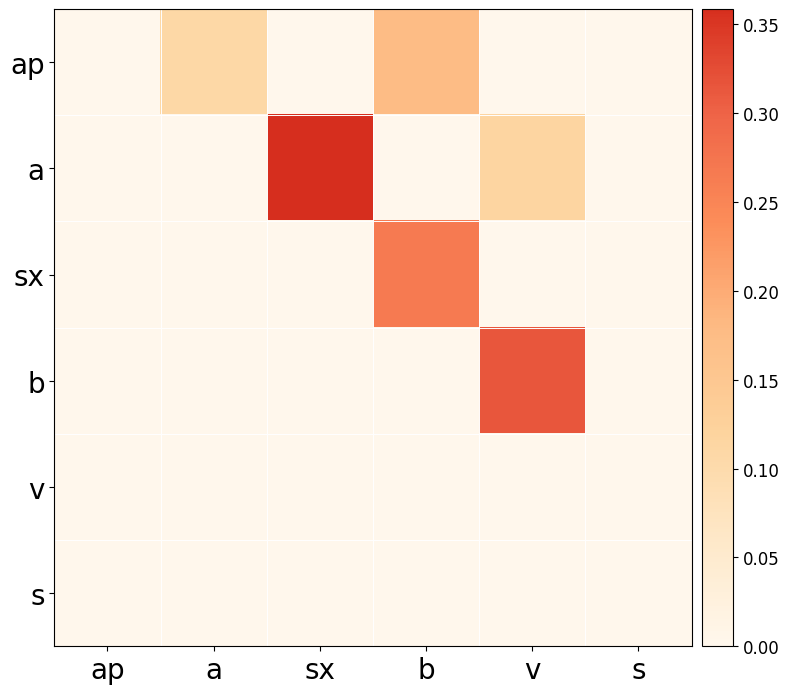

In [88]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    new_colors = cmap(np.linspace(minval, maxval, n))
    return LinearSegmentedColormap.from_list("trunc_cmap", new_colors)

def visualize_adjacency_matrix(adj_matrix, x_labels=None, y_labels=None):
    fig, ax = plt.subplots(figsize=(8, 8))

    # vmin/vmax
    vmin = np.min(adj_matrix)
    vmax = np.max(adj_matrix)
    if vmin == vmax:
        vmax = vmin + 1.0

    # colormap
    orig_cmap = plt.get_cmap("OrRd")
    trunc_cmap = truncate_colormap(orig_cmap, 0.0, 0.75)

    # heatmap
    im = ax.imshow(adj_matrix, cmap=trunc_cmap, vmin=vmin, vmax=vmax, aspect='equal')

    # grid lines
    ax.set_xticks(np.arange(-0.5, adj_matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, adj_matrix.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    # axis labels
    if x_labels is None:
        x_labels = [f"A{i}" for i in range(adj_matrix.shape[1])]
    if y_labels is None:
        y_labels = [f"A{i}" for i in range(adj_matrix.shape[0])]

    ax.set_xticks(range(adj_matrix.shape[1]))
    ax.set_yticks(range(adj_matrix.shape[0]))
    ax.set_xticklabels(x_labels, fontsize=20)
    ax.set_yticklabels(y_labels, fontsize=20)

    # ---------------------------------------------------
    # COLORBAR THAT MATCHES MATRIX HEIGHT
    # ---------------------------------------------------
    # Create separate axes for colorbar with matched height
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)

    # create colorbar in the new axis; it will match the height automatically
    cb = plt.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=12)

    # title
    #plt.title("Adjacency Matrix Visualization", fontsize=14)
    plt.tight_layout()
    plt.show()


file_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs_mtx/logs_adni_all/2025-06-23T12-49-18-textcond_six_10slice_reg5e8_epoch5_reg/CM-6000.csv"
adj = np.loadtxt(file_path, delimiter=",")
th_cm = adj.copy()
th_cm[np.abs(th_cm)<0.07]=0
adj = th_cm*1.5

# file_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/notebooks/saved_mtx/ADNI/SDCD.csv"
# adj = np.loadtxt(file_path, delimiter=",")
# file_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/notebooks/saved_mtx/ADNI/SDCD_threshold.csv"
# adj = np.loadtxt(file_path, delimiter=",")*adj

# # Example
# adj = np.array([
#     [0,0,0,0,0,0],
#     [0,0,0,0,0,0],
#     [0,0,0,0,0,0],
#     [0,0,0,0,0,0],
#     [0,0,0,0,0,0],
#     [0,0,0,0,0,0],
# ])

visualize_adjacency_matrix(
    adj,
    x_labels=["ap", "a", "sx", "b", "v", "s"],
    y_labels=["ap", "a", "sx", "b", "v", "s"]
)


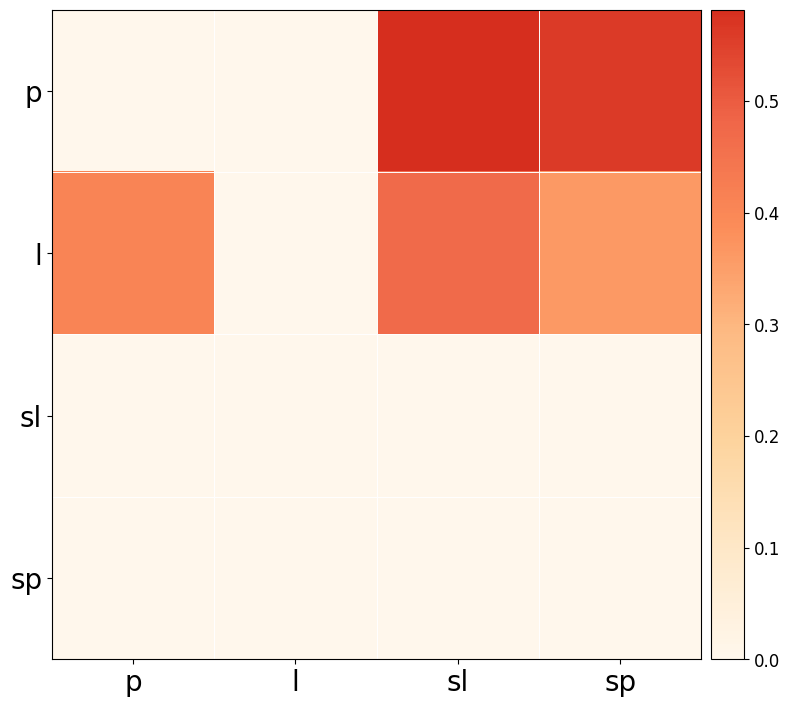

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    new_colors = cmap(np.linspace(minval, maxval, n))
    return LinearSegmentedColormap.from_list("trunc_cmap", new_colors)

def visualize_adjacency_matrix(adj_matrix, x_labels=None, y_labels=None):
    fig, ax = plt.subplots(figsize=(8, 8))

    # vmin/vmax
    vmin = np.min(adj_matrix)
    vmax = np.max(adj_matrix)
    if vmin == vmax:
        vmax = vmin + 1.0

    # colormap
    orig_cmap = plt.get_cmap("OrRd")
    trunc_cmap = truncate_colormap(orig_cmap, 0.0, 0.75)

    # heatmap
    im = ax.imshow(adj_matrix, cmap=trunc_cmap, vmin=vmin, vmax=vmax, aspect='equal')

    # grid lines
    ax.set_xticks(np.arange(-0.5, adj_matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, adj_matrix.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    # axis labels
    if x_labels is None:
        x_labels = [f"A{i}" for i in range(adj_matrix.shape[1])]
    if y_labels is None:
        y_labels = [f"A{i}" for i in range(adj_matrix.shape[0])]

    ax.set_xticks(range(adj_matrix.shape[1]))
    ax.set_yticks(range(adj_matrix.shape[0]))
    ax.set_xticklabels(x_labels, fontsize=20)
    ax.set_yticklabels(y_labels, fontsize=20)

    # ---------------------------------------------------
    # COLORBAR THAT MATCHES MATRIX HEIGHT
    # ---------------------------------------------------
    # Create separate axes for colorbar with matched height
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)

    # create colorbar in the new axis; it will match the height automatically
    cb = plt.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=12)

    # title
    #plt.title("Adjacency Matrix Visualization", fontsize=14)
    plt.tight_layout()
    plt.show()


# Example
file_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs_mtx/logs_pendulum_all/2025-02-24T23-11-29-accu100_DAG3_warmup_lr/CM-2000.csv"
adj = np.loadtxt(file_path, delimiter=",")
th_cm = adj.copy()
th_cm[np.abs(th_cm)<0.05]=0
adj = th_cm*5


#SDCD
# file_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/causal_discovery/saved_mtx/pendulum/SDCD.csv"
# adj = np.loadtxt(file_path, delimiter=",")
# file_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/causal_discovery/saved_mtx/pendulum/SDCD_threshold.csv"
# adj = np.loadtxt(file_path, delimiter=",")*adj

# adj = np.array([
#     [0,0,0,0],
#     [0,0,0,0],
#     [0,0,0,0],
#     [0,0,0,0]
# ])

visualize_adjacency_matrix(
    adj,
    x_labels=["p", "l", "sl", "sp"],
    y_labels=["p", "l", "sl", "sp"]
)


In [1]:
import numpy as np

file_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/causal_discovery/saved_mtx/pendulum/dagma_threshold.csv"
arr = np.loadtxt(file_path, delimiter=",")
print(arr)

[[0.         0.81890218 2.27238197 1.06864093]
 [0.         0.         2.56813849 0.        ]
 [0.         0.         0.         0.        ]
 [0.         1.33835736 0.         0.        ]]


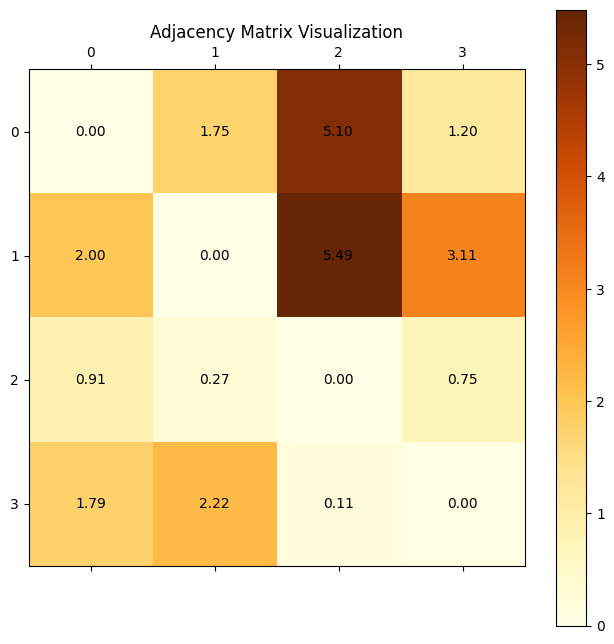

In [21]:
a = np.array([[0.        , 1.7505653 , 5.100335  , 1.1979084 ],
       [2.0000484 , 0.        , 5.4867415 , 3.1058004 ],
       [0.90680516, 0.27155477, 0.        , 0.747747  ],
       [1.7873861 , 2.2182434 , 0.11005053, 0.        ]])
visualize_adjacency_matrix(a)

In [11]:
# Imports
import sys
import numpy as np
from PIL import Image
from torchvision import transforms

img_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/counterfactual_benchmark/datasets/adni/preprocessing/preprocessed_data/002_S_0295/MPR__GradWarp__B1_Correction__N3__Scaled/2006-04-18_08_20_30.0/I45108/ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070319113623975_S13408_I45108_slice13.tiff'

image = Image.open(img_path)
image_array = np.array(image)
# Normalize the image (scale from min-max to 0-255)
image_array = (image_array - image_array.min()) / (image_array.max() - image_array.min()) * 255
# Convert to uint8 (required for RGB conversion)
image_array = image_array.astype(np.uint8)
# Convert back to a PIL image in RGB mode
image = Image.fromarray(image_array, mode="L")
if not image.mode == "RGB":
    image = image.convert("RGB")


image_transforms = transforms.Compose(
    [
        transforms.Pad(padding=6),
        transforms.Resize((256,256), interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.ToTensor(),
    ]
)
normalize_transforms = transforms.Compose(
        [
            transforms.Normalize([0.5], [0.5]),
        ]
    )
i_t = image_transforms(image)